### Lab 4 Momentum & Collisions

**Student:** Zaki Daouk  
**Date:** 2026-09-20

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Part A — 1D Collisions with Restitution

In [2]:
def collide_1d(m1, m2, u1, u2, e):
    """Return post-collision velocities using the coefficient of restitution e."""
    v1 = ((m1 - e * m2) * u1 + (1 + e) * m2 * u2) / (m1 + m2)
    v2 = ((1 + e) * m1 * u1 + (m2 - e * m1) * u2) / (m1 + m2)
    return v1, v2


def p_total(m1, m2, u1, u2):
    return m1 * u1 + m2 * u2


def ke_total(m1, m2, u1, u2):
    return 0.5 * m1 * u1**2 + 0.5 * m2 * u2**2


# Three limiting cases for perfectly elastic collisions (e = 1).
v1, v2 = collide_1d(1.0, 1.0, 3.0, 0.0, 1.0)
print(f"Equal masses: ({v1:.3f}, {v2:.3f})")
v1, v2 = collide_1d(0.1, 100.0, 3.0, 0.0, 1.0)
print(f"Light ball into heavy stationary ball: ({v1:.3f}, {v2:.3f})")
v1, v2 = collide_1d(100.0, 0.1, 3.0, 0.0, 1.0)
print(f"Heavy ball into light stationary ball: ({v1:.3f}, {v2:.3f})")

# Conservation check for the 2 kg and 3 kg blocks.
m1, m2, u1, u2 = 2.0, 3.0, 4.0, 0.0
for e in (1.0, 0.5, 0.0):
    v1, v2 = collide_1d(m1, m2, u1, u2, e)
    print(
        f"e={e:.1f}: p before={p_total(m1, m2, u1, u2):.3f}, "
        f"p after={p_total(m1, m2, v1, v2):.3f}, "
        f"KE before={ke_total(m1, m2, u1, u2):.3f}, "
        f"KE after={ke_total(m1, m2, v1, v2):.3f}"
    )

Equal masses: (0.000, 3.000)
Light ball into heavy stationary ball: (-2.994, 0.006)
Heavy ball into light stationary ball: (2.994, 5.994)
e=1.0: p before=8.000, p after=8.000, KE before=16.000, KE after=16.000
e=0.5: p before=8.000, p after=8.000, KE before=16.000, KE after=8.800
e=0.0: p before=8.000, p after=8.000, KE before=16.000, KE after=6.400


| $e$ | Total momentum before (kg m/s) | Total momentum after (kg m/s) | Total KE before (J) | Total KE after (J) |
|---:|---:|---:|---:|---:|
| 1.0 | 8.000 | 8.000 | 16.000 | 16.000 |
| 0.5 | 8.000 | 8.000 | 16.000 | 8.800 |
| 0.0 | 8.000 | 8.000 | 16.000 | 6.400 |

### Momentum for 1-D Collision Analysis
Total momentum is conserved and has the same before-and-after value for all three $e$ values, while kinetic energy drops as $e$ shrinks. The missing kinetic energy is converted into internal energy through deformation, heating, sound, and other dissipative effects during the collision.

### Part B — 2D Collisions in a Box

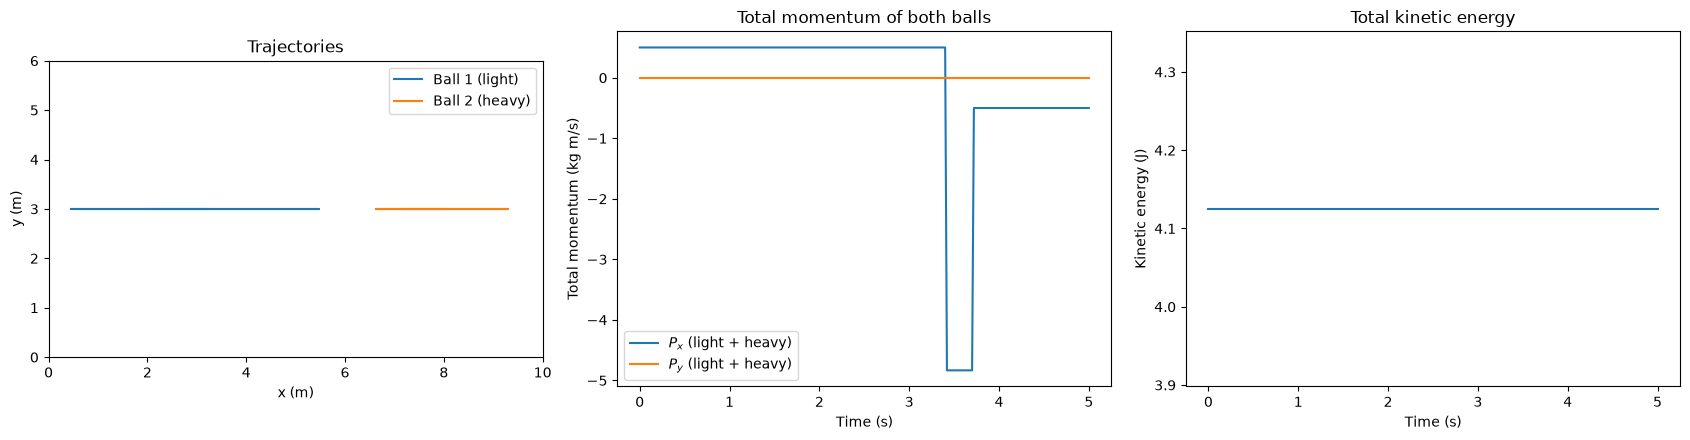

KE range: 4.125 to 4.125 J


In [3]:
def collide_2d(m1, m2, r1, r2, v1, v2, e):
    """Resolve a 2D collision along the line joining the ball centers."""
    normal = (r2 - r1) / np.linalg.norm(r2 - r1)
    u1n, u2n = np.dot(v1, normal), np.dot(v2, normal)
    v1t = v1 - u1n * normal
    v2t = v2 - u2n * normal
    new1n, new2n = collide_1d(m1, m2, u1n, u2n, e)

    return v1t + new1n * normal, v2t + new2n * normal


def bounce_off_walls(position, velocity, radius, width, height):
    """Reflect velocity and clamp a ball inside a rectangular box."""
    position = np.asarray(position, dtype=float).copy()
    velocity = np.asarray(velocity, dtype=float).copy()

    if position[0] - radius < 0 or position[0] + radius > width:
        velocity[0] *= -1
        position[0] = np.clip(position[0], radius, width - radius)
    if position[1] - radius < 0 or position[1] + radius > height:
        velocity[1] *= -1
        position[1] = np.clip(position[1], radius, height - radius)
    return position, velocity


# Simulation setup: two unequal balls on a collision course.
width, height = 10.0, 6.0
dt, steps, e = 0.02, 250, 1.0
bodies = [
    {
        "m": 1.0,
        "r": np.array([2.0, 3.0], dtype=float),
        "v": np.array([2.5, 0.0], dtype=float),
        "radius": 0.45,
    },
    {
        "m": 2.0,
        "r": np.array([8.0, 3.0], dtype=float),
        "v": np.array([-1.0, 0.0], dtype=float),
        "radius": 0.70,
    },
]
light_ball, heavy_ball = bodies

times = np.arange(steps + 1) * dt
positions1 = [light_ball["r"].copy()]
positions2 = [heavy_ball["r"].copy()]
momentum_history = [sum((body["m"] * body["v"] for body in bodies), start=np.zeros(2))]
ke_history = [sum(0.5 * body["m"] * np.dot(body["v"], body["v"]) for body in bodies)]

for _ in range(steps):
    for body in bodies:
        body["r"] += body["v"] * dt
        body["r"], body["v"] = bounce_off_walls(
            body["r"], body["v"], body["radius"], width, height
        )

    separation_vector = heavy_ball["r"] - light_ball["r"]
    separation = np.linalg.norm(separation_vector)
    approaching = np.dot(heavy_ball["v"] - light_ball["v"], separation_vector) < 0
    combined_radius = light_ball["radius"] + heavy_ball["radius"]
    if separation < combined_radius and approaching:
        light_ball["v"], heavy_ball["v"] = collide_2d(
            light_ball["m"],
            heavy_ball["m"],
            light_ball["r"],
            heavy_ball["r"],
            light_ball["v"],
            heavy_ball["v"],
            e,
        )
        normal = separation_vector / separation
        overlap = combined_radius - separation
        light_ball["r"] -= (
            heavy_ball["m"] / (light_ball["m"] + heavy_ball["m"])
        ) * overlap * normal
        heavy_ball["r"] += (
            light_ball["m"] / (light_ball["m"] + heavy_ball["m"])
        ) * overlap * normal

    positions1.append(light_ball["r"].copy())
    positions2.append(heavy_ball["r"].copy())
    momentum_history.append(
        sum((body["m"] * body["v"] for body in bodies), start=np.zeros(2))
    )
    ke_history.append(
        sum(0.5 * body["m"] * np.dot(body["v"], body["v"]) for body in bodies)
    )

positions1 = np.array(positions1)
positions2 = np.array(positions2)
momentum_history = np.array(momentum_history)
ke_history = np.array(ke_history)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
axes[0].plot(positions1[:, 0], positions1[:, 1], label="Ball 1 (light)")
axes[0].plot(positions2[:, 0], positions2[:, 1], label="Ball 2 (heavy)")
axes[0].set(xlim=(0, width), ylim=(0, height), xlabel="x (m)", ylabel="y (m)", title="Trajectories")
axes[0].set_aspect("equal")
axes[0].legend()

axes[1].plot(times, momentum_history[:, 0], label="$P_x$ (light + heavy)")
axes[1].plot(times, momentum_history[:, 1], label="$P_y$ (light + heavy)")
axes[1].set(xlabel="Time (s)", ylabel="Total momentum (kg m/s)", title="Total momentum of both balls")
axes[1].legend()

axes[2].plot(times, ke_history)
axes[2].set(xlabel="Time (s)", ylabel="Kinetic energy (J)", title="Total kinetic energy")

plt.tight_layout()
plt.show()
print(f"KE range: {ke_history.min():.3f} to {ke_history.max():.3f} J")

### 2-D Collision Interpretation

With `e = 1` and elastic walls, total kinetic energy should remain constant because neither the ball-ball collisions nor the wall bounces remove kinetic energy. The simulation gives `KE = 4.125 J` at every recorded time, so it behaves as expected.

Total momentum is conserved during ball-ball collisions, but it changes when a ball bounces from a wall. The wall is an external object that exerts an impulse on the two-ball system, transferring momentum to or from the box; therefore, the balls' momentum alone is not conserved during wall collisions.

### Part C — Inelastic Collisions & Energy Accounting


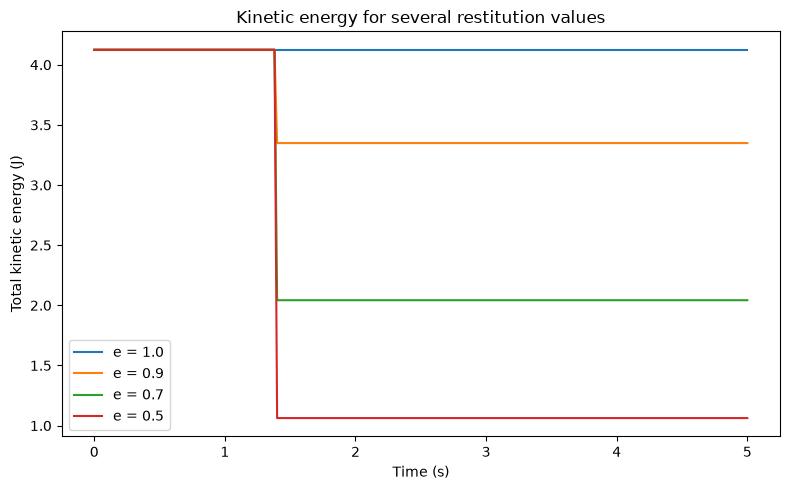

First ball-ball collision KE loss:
 e     measured fraction     theoretical fraction
1.0       0.000                 0.000
0.9       0.188                 0.188
0.7       0.505                 0.505
0.5       0.742                 0.742


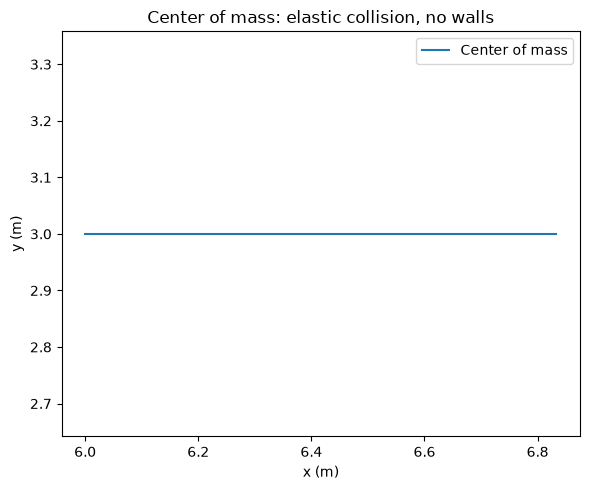

Expected center-of-mass velocity: (0.167, 0.000) m/s
Maximum center-of-mass velocity error: 0.000 m/s
e=1.0: maximum KE increase = 0.000 J
e=0.9: maximum KE increase = 0.000 J
e=0.7: maximum KE increase = 0.000 J
e=0.5: maximum KE increase = 0.000 J


In [4]:
def simulate_2d(e, walls=True, steps=250):
    """Run the same two-ball setup for a chosen restitution coefficient."""
    width, height = 10.0, 6.0
    dt = 0.02
    bodies = [
        {
            "m": 1.0,
            "r": np.array([2.0, 3.0], dtype=float),
            "v": np.array([2.5, 0.0], dtype=float),
            "radius": 0.45,
        },
        {
            "m": 2.0,
            "r": np.array([8.0, 3.0], dtype=float),
            "v": np.array([-1.0, 0.0], dtype=float),
            "radius": 0.70,
        },
    ]
    light_ball, heavy_ball = bodies

    times = np.arange(steps + 1) * dt
    positions1 = [light_ball["r"].copy()]
    positions2 = [heavy_ball["r"].copy()]
    momentum_history = [sum((body["m"] * body["v"] for body in bodies), start=np.zeros(2))]
    ke_history = [sum(0.5 * body["m"] * np.dot(body["v"], body["v"]) for body in bodies)]
    first_collision = None

    for step in range(steps):
        for body in bodies:
            body["r"] += body["v"] * dt
            if walls:
                body["r"], body["v"] = bounce_off_walls(
                    body["r"], body["v"], body["radius"], width, height
                )

        separation_vector = heavy_ball["r"] - light_ball["r"]
        separation = np.linalg.norm(separation_vector)
        approaching = np.dot(heavy_ball["v"] - light_ball["v"], separation_vector) < 0
        combined_radius = light_ball["radius"] + heavy_ball["radius"]
        if separation < combined_radius and approaching:
            ke_before = sum(
                0.5 * body["m"] * np.dot(body["v"], body["v"]) for body in bodies
            )
            light_ball["v"], heavy_ball["v"] = collide_2d(
                light_ball["m"],
                heavy_ball["m"],
                light_ball["r"],
                heavy_ball["r"],
                light_ball["v"],
                heavy_ball["v"],
                e,
            )
            ke_after = sum(
                0.5 * body["m"] * np.dot(body["v"], body["v"]) for body in bodies
            )
            if first_collision is None:
                first_collision = (step + 1, ke_before, ke_after)

            # Separate the balls without shifting their center of mass.
            normal = separation_vector / separation
            overlap = combined_radius - separation
            light_ball["r"] -= (
                heavy_ball["m"] / (light_ball["m"] + heavy_ball["m"])
            ) * overlap * normal
            heavy_ball["r"] += (
                light_ball["m"] / (light_ball["m"] + heavy_ball["m"])
            ) * overlap * normal

        positions1.append(light_ball["r"].copy())
        positions2.append(heavy_ball["r"].copy())
        momentum_history.append(
            sum((body["m"] * body["v"] for body in bodies), start=np.zeros(2))
        )
        ke_history.append(
            sum(0.5 * body["m"] * np.dot(body["v"], body["v"]) for body in bodies)
        )

    return {
        "times": times,
        "positions1": np.array(positions1),
        "positions2": np.array(positions2),
        "momentum": np.array(momentum_history),
        "ke": np.array(ke_history),
        "first_collision": first_collision,
        "masses": tuple(body["m"] for body in bodies),
    }


# Sweep restitution values with identical initial conditions.
restitution_values = (1.0, 0.9, 0.7, 0.5)
sweep_results = {e_value: simulate_2d(e_value) for e_value in restitution_values}

plt.figure(figsize=(8, 5))
for e_value, result in sweep_results.items():
    plt.plot(result["times"], result["ke"], label=f"e = {e_value:.1f}")
plt.xlabel("Time (s)")
plt.ylabel("Total kinetic energy (J)")
plt.title("Kinetic energy for several restitution values")
plt.legend()
plt.tight_layout()
plt.show()

# Compare measured first-collision losses with the head-on theoretical prediction.
m1, m2 = sweep_results[1.0]["masses"]
relative_speed = 2.5 - (-1.0)
reduced_mass = m1 * m2 / (m1 + m2)
initial_ke = 0.5 * m1 * 2.5**2 + 0.5 * m2 * (-1.0)**2
print("First ball-ball collision KE loss:")
print(" e     measured fraction     theoretical fraction")
for e_value in restitution_values:
    _, ke_before, ke_after = sweep_results[e_value]["first_collision"]
    measured_fraction = (ke_before - ke_after) / ke_before
    theoretical_fraction = (
        0.5 * reduced_mass * (1 - e_value**2) * relative_speed**2 / initial_ke
    )
    print(f"{e_value:3.1f}       {measured_fraction:.3f}                 {theoretical_fraction:.3f}")

# Elastic, wall-free center-of-mass test.
free_result = simulate_2d(1.0, walls=False, steps=250)
positions1 = free_result["positions1"]
positions2 = free_result["positions2"]
center_of_mass = (m1 * positions1 + m2 * positions2) / (m1 + m2)
cm_velocity = np.diff(center_of_mass, axis=0) / (free_result["times"][1] - free_result["times"][0])
expected_cm_velocity = (m1 * np.array([2.5, 0.0]) + m2 * np.array([-1.0, 0.0])) / (m1 + m2)
cm_velocity_error = np.max(np.abs(cm_velocity - expected_cm_velocity))

plt.figure(figsize=(6, 5))
plt.plot(center_of_mass[:, 0], center_of_mass[:, 1], label="Center of mass")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Center of mass: elastic collision, no walls")
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.show()
print(
    "Expected center-of-mass velocity: "
    f"({expected_cm_velocity[0]:.3f}, {expected_cm_velocity[1]:.3f}) m/s"
)
print(f"Maximum center-of-mass velocity error: {cm_velocity_error:.3f} m/s")

# A useful diagnostic: with e <= 1, the discrete KE should never increase.
for e_value, result in sweep_results.items():
    ke_differences = np.diff(result["ke"])
    print(f"e={e_value:.1f}: maximum KE increase = {ke_differences.max():.3f} J")

### KE vs Time for Restitution and COM Conservation Analysis

For `e < 1`, total kinetic energy drops at the first ball-ball collision and then remains constant during the later elastic wall bounces. In this run, KE never increases for any tested value of `e`; an increase would indicate an implementation error, such as an incorrect collision formula, a sign error in the normal direction, or a bad overlap correction.

"KE never increases" is a useful test even without an exact solution because it follows directly from the restitution condition `0 <= e <= 1`: the relative normal speed after impact is no larger than before impact. It is therefore a physical invariant that can expose bugs in a complicated simulation. The wall-free center-of-mass test is another strong check: with no external force, total momentum is constant, so the center of mass must move in a straight line at constant velocity through the collision.

 ### Bonus Challenge — Gas in a Box

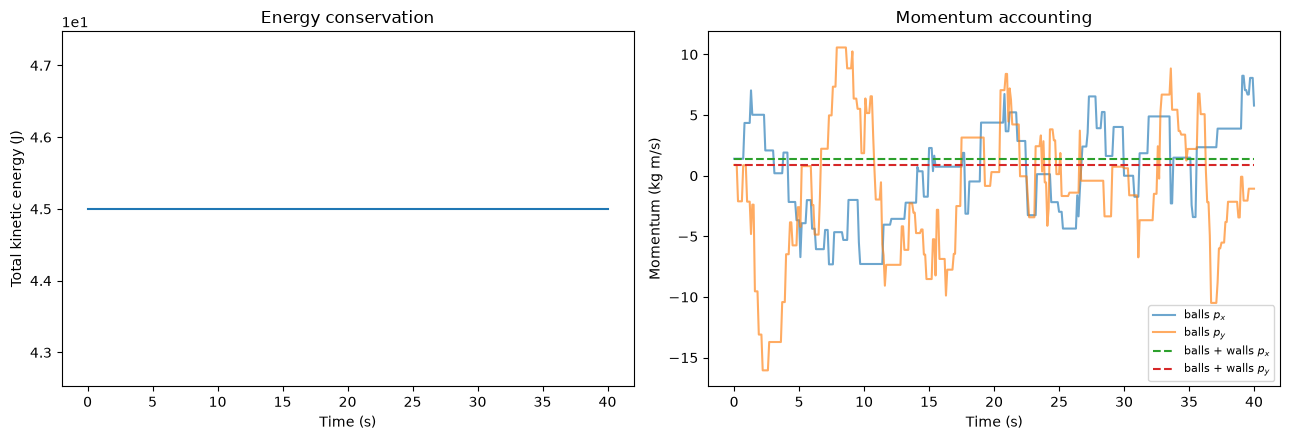

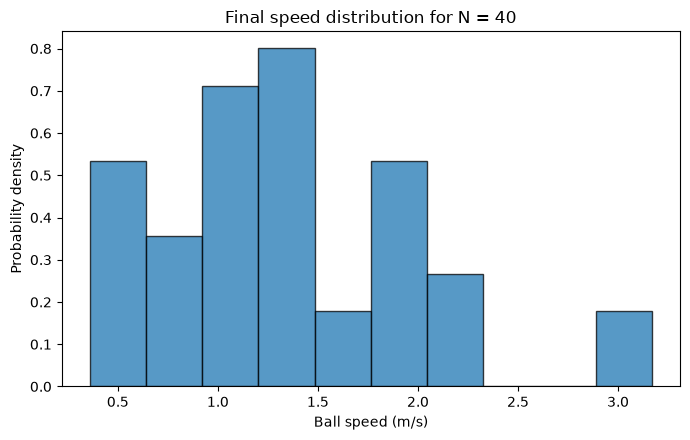

Initial KE: 45.000 J
Maximum absolute KE drift: 0.000 J
Maximum ball-momentum drift: 16.936 kg m/s
Maximum balls-plus-walls momentum drift: 0.000 kg m/s
Initial speed: 1.500 m/s
Final speed range: 0.360 to 3.169 m/s


In [5]:
# Ideal-gas model: many identical elastic balls in a box.
rng = np.random.default_rng(311)
N = 40
width, height = 20.0, 12.0
radius = 0.25
mass = 1.0
speed0 = 1.5
dt = 0.01
steps = 4000
sample_every = 10

# Rejection sampling creates non-overlapping initial positions.
positions = []
while len(positions) < N:
    candidate = rng.uniform([radius, radius], [width - radius, height - radius])
    if all(np.linalg.norm(candidate - position) >= 2 * radius for position in positions):
        positions.append(candidate)
positions = np.array(positions)

angles = rng.uniform(0, 2 * np.pi, N)
velocities = speed0 * np.column_stack((np.cos(angles), np.sin(angles)))
wall_momentum = np.zeros(2)

sample_times = [0.0]
ke_history = [0.5 * mass * np.sum(velocities**2)]
momentum_history = [mass * np.sum(velocities, axis=0)]
wall_momentum_history = [wall_momentum.copy()]

for step in range(steps):
    # Euler-Cromer position update. There are no external forces in this model.
    positions += velocities * dt

    for i in range(N):
        velocity_before_wall = velocities[i].copy()
        positions[i], velocities[i] = bounce_off_walls(
            positions[i], velocities[i], radius, width, height
        )
        # The wall receives the impulse opposite to the ball's velocity change.
        wall_momentum -= mass * (velocities[i] - velocity_before_wall)

    # Check each unique pair exactly once.
    for i in range(N):
        for j in range(i + 1, N):
            separation_vector = positions[j] - positions[i]
            separation = np.linalg.norm(separation_vector)
            approaching = np.dot(velocities[j] - velocities[i], separation_vector) < 0
            if separation > 0 and separation < 2 * radius and approaching:
                velocities[i], velocities[j] = collide_2d(
                    mass,
                    mass,
                    positions[i],
                    positions[j],
                    velocities[i],
                    velocities[j],
                    e=1.0,
                )

                # For identical balls, symmetric separation preserves the CM.
                normal = separation_vector / separation
                overlap = 2 * radius - separation
                positions[i] -= 0.5 * overlap * normal
                positions[j] += 0.5 * overlap * normal

    if (step + 1) % sample_every == 0:
        sample_times.append((step + 1) * dt)
        ke_history.append(0.5 * mass * np.sum(velocities**2))
        momentum_history.append(mass * np.sum(velocities, axis=0))
        wall_momentum_history.append(wall_momentum.copy())

sample_times = np.array(sample_times)
ke_history = np.array(ke_history)
momentum_history = np.array(momentum_history)
wall_momentum_history = np.array(wall_momentum_history)
total_momentum_history = momentum_history + wall_momentum_history
final_speeds = np.linalg.norm(velocities, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(sample_times, ke_history)
axes[0].set(xlabel="Time (s)", ylabel="Total kinetic energy (J)", title="Energy conservation")
axes[0].ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))
axes[1].plot(sample_times, momentum_history[:, 0], alpha=0.65, label="balls $p_x$")
axes[1].plot(sample_times, momentum_history[:, 1], alpha=0.65, label="balls $p_y$")
axes[1].plot(sample_times, total_momentum_history[:, 0], "--", label="balls + walls $p_x$")
axes[1].plot(sample_times, total_momentum_history[:, 1], "--", label="balls + walls $p_y$")
axes[1].set(xlabel="Time (s)", ylabel="Momentum (kg m/s)", title="Momentum accounting")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.hist(final_speeds, bins=10, density=True, edgecolor="black", alpha=0.75)
plt.xlabel("Ball speed (m/s)")
plt.ylabel("Probability density")
plt.title(f"Final speed distribution for N = {N}")
plt.tight_layout()
plt.show()

print(f"Initial KE: {ke_history[0]:.3f} J")
print(f"Maximum absolute KE drift: {np.max(np.abs(ke_history - ke_history[0])):.3f} J")
print(f"Maximum ball-momentum drift: {np.max(np.abs(momentum_history - momentum_history[0])):.3f} kg m/s")
print(f"Maximum balls-plus-walls momentum drift: {np.max(np.abs(total_momentum_history - total_momentum_history[0])):.3f} kg m/s")
print(f"Initial speed: {speed0:.3f} m/s")
print(f"Final speed range: {final_speeds.min():.3f} to {final_speeds.max():.3f} m/s")

### Ideal Gas: Balls in a Box Analysis

Although every ball starts with the same speed, collisions continually exchange velocity components between balls. The total kinetic energy remains fixed, but it is redistributed among the particles, so individual speeds spread into a distribution with the beginnings of the Maxwell-Boltzmann shape. In statistical mechanics, temperature measures the average kinetic energy per particle, while the distribution describes how that energy is shared across the ensemble; temperature does not require every particle to have the same speed. The balls' momentum changes when they bounce from the walls because the walls exert external impulses on the ball-only subsystem. When the wall momentum is included, the combined balls-plus-walls momentum is conserved. This conservation check is especially useful because it tests the pair loop, wall handling, and impulse signs even when there is no simple analytic trajectory for all 40 balls.